# 03 — Eczema Detection Pipeline

End-to-end inference + experiments from the proposal:

- **Exp 1** — severity ablation (acc, macro-F1, per-class P/R, confusion matrices)
- **Exp 2** — Grad-CAM heatmaps + Average Drop / Increase (Chattopadhay 2018)

Models in `models/` ingest raw [0, 255] floats; `preprocess_input` is baked in. Do **not** divide by 255 here.

In [10]:
import os, json
from pathlib import Path

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

DATA = Path('data')
MODELS = Path('models')
IMG_SIZE = (224, 224)

VALIDITY_LABELS = ['not a skin image', 'human skin image']
ECZEMA_LABELS   = ['clear skin', 'eczema']
SEVERITY_LABELS = ['mild', 'moderate', 'severe']


## 1. Load models

Best severity variant chosen by `test_accuracy` in `models/training_history.json`.

In [11]:
@keras.utils.register_keras_serializable()
class ChannelPool(layers.Layer):
    def call(self, x):
        avg = tf.reduce_mean(x, axis=-1, keepdims=True)
        mx  = tf.reduce_max(x, axis=-1, keepdims=True)
        return tf.concat([avg, mx], axis=-1)

skin   = keras.models.load_model(MODELS / 'stage1_skin.keras')
eczema = keras.models.load_model(MODELS / 'stage2_eczema.keras')

_PREF_ORDER = ['stage3_variant_d', 'stage3_variant_c',
               'stage3_variant_b', 'stage3_variant_a']

def load_best_severity():
    available = [n for n in _PREF_ORDER if (MODELS / f'{n}.keras').exists()]
    if not available:
        raise FileNotFoundError('no severity model found under models/')
    hist_path = MODELS / 'training_history.json'
    if hist_path.exists():
        records = json.loads(hist_path.read_text())
        scored = [(n, records[n]['test_accuracy'])
                  for n in available if n in records and 'test_accuracy' in records[n]]
        if scored:
            best, acc = max(scored, key=lambda kv: kv[1])
            print(f'severity model: {best}  (test_acc={acc:.4f})')
            return keras.models.load_model(MODELS / f'{best}.keras'), best
    name = available[0]
    print(f'severity model: {name}  (no history file — fallback by order)')
    return keras.models.load_model(MODELS / f'{name}.keras'), name

severity, severity_name = load_best_severity()

severity model: stage3_variant_b  (test_acc=0.6436)


## 2. Pipeline

In [12]:
def preprocess(image_path_or_array):
    if isinstance(image_path_or_array, (str, Path)):
        img = Image.open(image_path_or_array).convert('RGB').resize(IMG_SIZE)
        arr = np.array(img)
    else:
        arr = np.asarray(image_path_or_array)
        if arr.shape[:2] != IMG_SIZE:
            arr = np.array(Image.fromarray(arr.astype('uint8')).resize(IMG_SIZE))
    return arr.astype('float32')[None, ...]

def run_pipeline(image_path):
    x = preprocess(image_path)
    s1 = skin.predict(x, verbose=0)[0]
    i1 = int(np.argmax(s1))
    result = {
        'image': str(image_path),
        'stage1': VALIDITY_LABELS[i1],
        'stage1_conf': float(s1[i1]),
    }
    if i1 == 0:
        result['stage2'] = '—'; result['stage3'] = '—'
        return result
    s2 = eczema.predict(x, verbose=0)[0]
    i2 = int(np.argmax(s2))
    result['stage2'] = ECZEMA_LABELS[i2]; result['stage2_conf'] = float(s2[i2])
    if i2 == 0:
        result['stage3'] = '—'
        return result
    s3 = severity.predict(x, verbose=0)[0]
    i3 = int(np.argmax(s3))
    result['stage3'] = SEVERITY_LABELS[i3]; result['stage3_conf'] = float(s3[i3])
    result['severity_probs'] = {SEVERITY_LABELS[k]: float(s3[k]) for k in range(3)}
    return result

## 3. Sanity check

In [13]:
import random
random.seed(0)
samples = []
for cls in ['eczema', 'clearSkin', 'invalid', 'mild', 'moderate', 'severe']:
    files = list((DATA / 'test' / cls).glob('*'))
    if files:
        samples.append(random.choice(files))

print(f"{'image':<40} {'stage1':<20} {'stage2':<14} {'stage3':<12}")
print('-' * 90)
for p in samples:
    r = run_pipeline(p)
    name = f"{p.parent.name}/{p.name}"[-39:]
    s1 = f"{r['stage1']} ({r.get('stage1_conf',0):.2f})"
    s2 = r.get('stage2', '—'); s3 = r.get('stage3', '—')
    print(f"{name:<40} {s1:<20} {s2:<14} {s3:<12}")


image                                    stage1               stage2         stage3      
------------------------------------------------------------------------------------------
eczema/eczema_00939_11IMG001.jpg         human skin image (1.00) eczema         moderate    
rSkin/clear_00061_pigmented-bands-6.jpg  human skin image (1.00) clear skin     —           
invalid/invalid_02232.jpg                not a skin image (1.00) —              —           
mild/mild_00327_eczema-nummular-11.jpg   human skin image (1.00) eczema         moderate    
e/moderate_00271_eczema-subacute-58.jpg  human skin image (1.00) eczema         mild        
severe/severe_00044_eczema-acute-21.jpg  human skin image (1.00) clear skin     —           


## 4. Experiment 1 — severity-stage quantitative eval

Evaluates on the held-out severity test set: overall accuracy, macro-F1,
per-class precision/recall, and the confusion matrix. Runs across all
available trained variants so the ablation table can be filled directly
from this output.

In [14]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix,
    classification_report
)

# Build a deterministic test-set tensor — no rescaling here, models
# bake their own preprocess_input.
def load_stage3_test():
    return keras.utils.image_dataset_from_directory(
        DATA / 'test',
        labels='inferred', label_mode='int',
        class_names=SEVERITY_LABELS,
        image_size=IMG_SIZE, batch_size=32, shuffle=False,
    )

test_ds = load_stage3_test()
y_true = np.concatenate([y.numpy() for _, y in test_ds])
print(f'test samples: {len(y_true)}')

def evaluate_variant(name):
    p = MODELS / f'{name}.keras'
    if not p.exists():
        return None
    model = keras.models.load_model(p)
    preds = []
    for x, _ in test_ds:
        preds.append(np.argmax(model.predict(x, verbose=0), axis=1))
    y_pred = np.concatenate(preds)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    prec, rec, f1c, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0)
    cm  = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    return {
        'name': name, 'acc': acc, 'macro_f1': f1,
        'per_class': {SEVERITY_LABELS[k]: {
            'P': float(prec[k]), 'R': float(rec[k]),
            'F1': float(f1c[k]), 'support': int(sup[k])
        } for k in range(3)},
        'cm': cm.tolist(),
        'y_pred': y_pred,
    }

ablation = [r for r in (evaluate_variant(n) for n in
            ['stage3_variant_a', 'stage3_variant_b',
             'stage3_variant_c', 'stage3_variant_d']) if r]

# --- Headline ablation table -------------------------------------------------
print(f"\n{'variant':<22} {'acc':>7} {'macro-F1':>10}   per-class F1 (mild/mod/sev)")
print('-' * 80)
for r in ablation:
    f1s = [r['per_class'][c]['F1'] for c in SEVERITY_LABELS]
    print(f"  {r['name']:<20} {r['acc']:>7.4f} {r['macro_f1']:>10.4f}   "
          f"{f1s[0]:.3f} / {f1s[1]:.3f} / {f1s[2]:.3f}")

# --- Per-class precision / recall breakdown ---------------------------------
print('\nPer-class precision / recall')
print('-' * 80)
for r in ablation:
    print(f"\n  {r['name']}")
    for c in SEVERITY_LABELS:
        m = r['per_class'][c]
        print(f"    {c:<10}  P={m['P']:.3f}  R={m['R']:.3f}  "
              f"F1={m['F1']:.3f}  (n={m['support']})")

# --- Full sklearn report for the best variant -------------------------------
best = max(ablation, key=lambda r: r['acc'])
print(f"\nClassification report — best variant ({best['name']})")
print('-' * 80)
print(classification_report(y_true, best['y_pred'],
                            target_names=SEVERITY_LABELS, digits=3,
                            zero_division=0))


Found 202 files belonging to 3 classes.
test samples: 202

variant                    acc   macro-F1   per-class F1 (mild/mod/sev)
--------------------------------------------------------------------------------
  stage3_variant_a      0.5842     0.5532   0.514 / 0.651 / 0.494
  stage3_variant_b      0.6436     0.6401   0.583 / 0.670 / 0.667
  stage3_variant_c      0.6238     0.6204   0.560 / 0.656 / 0.645
  stage3_variant_d      0.5396     0.5360   0.562 / 0.545 / 0.500

Per-class precision / recall
--------------------------------------------------------------------------------

  stage3_variant_a
    mild        P=0.600  R=0.450  F1=0.514  (n=60)
    moderate    P=0.587  R=0.732  F1=0.651  (n=97)
    severe      P=0.556  R=0.444  F1=0.494  (n=45)

  stage3_variant_b
    mild        P=0.583  R=0.583  F1=0.583  (n=60)
    moderate    P=0.681  R=0.660  F1=0.670  (n=97)
    severe      P=0.646  R=0.689  F1=0.667  (n=45)

  stage3_variant_c
    mild        P=0.538  R=0.583  F1=0.560  (n=

### Confusion matrices (per variant)

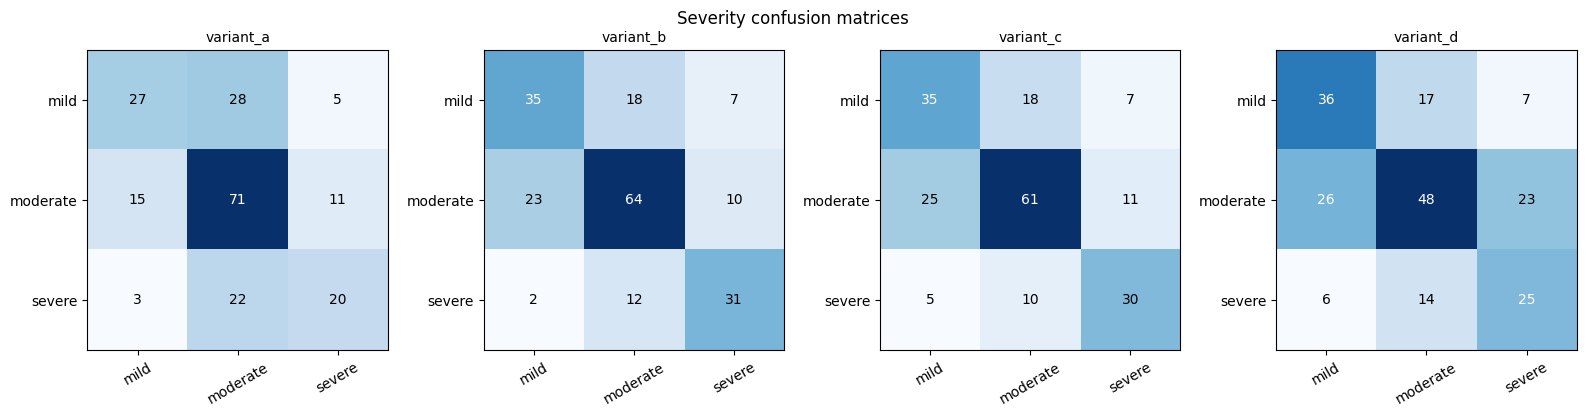

In [15]:
fig, axes = plt.subplots(1, len(ablation), figsize=(4*len(ablation), 4))
if len(ablation) == 1: axes = [axes]
for ax, r in zip(axes, ablation):
    cm = np.array(r['cm'])
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(3)); ax.set_xticklabels(SEVERITY_LABELS, rotation=30)
    ax.set_yticks(range(3)); ax.set_yticklabels(SEVERITY_LABELS)
    ax.set_title(r['name'].replace('stage3_', ''), fontsize=10)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() * 0.5 else 'black', fontsize=10)
plt.suptitle('Severity confusion matrices')
plt.tight_layout(); plt.show()


## 5. Experiment 2 — Grad-CAM explainability

Generates gradient-based heatmaps and quantifies faithfulness with
**Average Drop** and **Average Increase** (Chattopadhay et al. 2018).

- *Average Drop*: how much does the predicted probability drop when only the
  Grad-CAM-highlighted region is kept? Lower is better (highlighted region
  matters less).
- *Average Increase*: fraction of images where masked input gives a higher
  probability than original. Higher is better.

We compare the baseline (Variant A) with the best improved variant.

In [16]:
def find_last_conv(model):
    '''Walk the model graph (recursing into nested Models such as the
    EfficientNet backbone) and return the deepest Conv2D / DepthwiseConv2D
    layer. Skips augmentation/preprocessing wrappers.'''
    candidate = None
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            inner = find_last_conv(layer)
            if inner is not None:
                candidate = inner
        elif isinstance(layer, (layers.Conv2D, layers.DepthwiseConv2D)):
            candidate = layer
    return candidate

def grad_cam(model, image, class_idx=None):
    '''Compute a Grad-CAM heatmap for a single (1, H, W, 3) input.

    `image` is expected in the model's native input range — for the
    self-contained models in this project that means raw [0, 255] floats.
    '''
    last_conv = find_last_conv(model)
    if last_conv is None:
        raise RuntimeError('Could not locate a Conv2D layer for Grad-CAM.')
    grad_model = keras.Model(inputs=model.inputs,
                             outputs=[last_conv.output, model.output])
    with tf.GradientTape() as tape:
        conv_feats, preds = grad_model(image, training=False)
        if class_idx is None:
            class_idx = int(tf.argmax(preds[0]))
        target = preds[:, class_idx]
    grads = tape.gradient(target, conv_feats)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam = tf.reduce_sum(conv_feats[0] * pooled, axis=-1)
    cam = tf.maximum(cam, 0)
    cam = cam / (tf.reduce_max(cam) + 1e-9)
    return cam.numpy()

def cam_to_overlay(cam, img_hw=(224, 224)):
    from PIL import Image as PILImage
    cam_img = PILImage.fromarray(np.uint8(255 * cam)).resize(img_hw, PILImage.BILINEAR)
    return np.array(cam_img) / 255.0


### Side-by-side heatmaps (baseline vs best improved)

/opt/homebrew/Caskroom/miniconda/base/envs/deep-learning/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['image']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


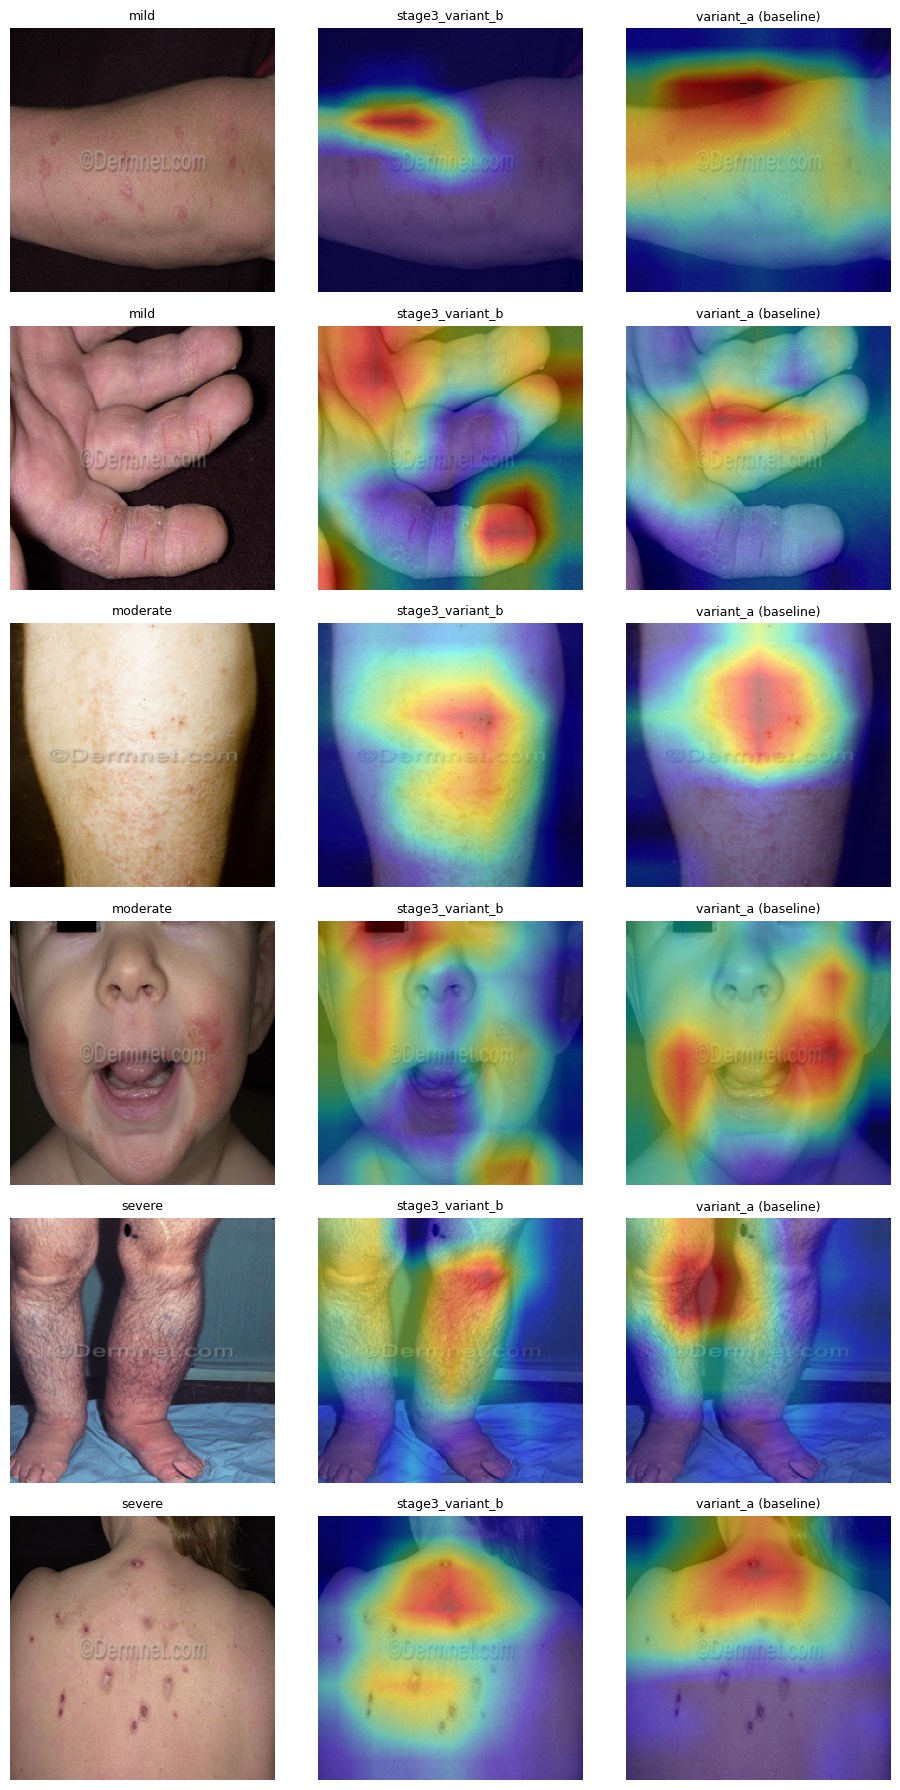

In [17]:
# Load baseline Variant A (if present) to compare against the 'best' model.
baseline_model = None
if (MODELS / 'stage3_variant_a.keras').exists() and severity_name != 'stage3_variant_a':
    baseline_model = keras.models.load_model(MODELS / 'stage3_variant_a.keras')

# Pick a few eczema test images — two per severity class
sev_dirs = [DATA / 'test' / c for c in SEVERITY_LABELS]
grid_samples = []
for d in sev_dirs:
    files = sorted(d.glob('*'))[:2]
    grid_samples.extend(files)

n = len(grid_samples)
cols = 3 if baseline_model is not None else 2
fig, axes = plt.subplots(n, cols, figsize=(cols * 3.2, n * 3.0))
if n == 1: axes = axes[None, :]
for row, img_path in enumerate(grid_samples):
    raw = np.array(Image.open(img_path).convert('RGB').resize(IMG_SIZE))
    # Models bake their own preprocess_input → feed raw [0,255] floats.
    x = raw[None, ...].astype('float32')
    axes[row, 0].imshow(raw); axes[row, 0].axis('off')
    axes[row, 0].set_title(img_path.parent.name, fontsize=9)
    # Best model heatmap
    cam = grad_cam(severity, x)
    overlay = cam_to_overlay(cam)
    axes[row, 1].imshow(raw)
    axes[row, 1].imshow(overlay, cmap='jet', alpha=0.45)
    axes[row, 1].axis('off'); axes[row, 1].set_title(severity_name, fontsize=9)
    # Baseline heatmap for comparison
    if baseline_model is not None and cols == 3:
        cam_b = grad_cam(baseline_model, x)
        overlay_b = cam_to_overlay(cam_b)
        axes[row, 2].imshow(raw)
        axes[row, 2].imshow(overlay_b, cmap='jet', alpha=0.45)
        axes[row, 2].axis('off'); axes[row, 2].set_title('variant_a (baseline)', fontsize=9)
plt.tight_layout(); plt.show()


### Average Drop / Average Increase

In [18]:
def avg_drop_increase(model, image_paths, threshold=0.5):
    '''Chattopadhay et al. (2018) Average Drop / Average Increase.

    For each image: keep only the Grad-CAM-highlighted pixels (binary mask
    above `threshold`), feed the masked image, and compare the predicted
    probability of the originally-chosen class.
    '''
    drops, increases = [], []
    for p in image_paths:
        raw = np.array(Image.open(p).convert('RGB').resize(IMG_SIZE))
        # Models bake preprocess_input → raw [0,255] floats throughout.
        x = raw[None, ...].astype('float32')
        probs = model.predict(x, verbose=0)[0]
        c = int(np.argmax(probs))
        p_orig = float(probs[c])
        cam = grad_cam(model, x, class_idx=c)
        mask = cam_to_overlay(cam) >= threshold
        masked = (raw * mask[..., None]).astype('float32')
        x_m = masked[None, ...]
        p_masked = float(model.predict(x_m, verbose=0)[0][c])
        drops.append(max(0.0, (p_orig - p_masked) / (p_orig + 1e-9)))
        increases.append(1.0 if p_masked > p_orig else 0.0)
    return {
        'avg_drop_pct': 100 * float(np.mean(drops)),
        'avg_increase_pct': 100 * float(np.mean(increases)),
        'n': len(image_paths),
    }

# Small evaluation set: up to 10 random images per severity class.
rng = np.random.default_rng(0)
eval_paths = []
for c in SEVERITY_LABELS:
    files = list((DATA / 'test' / c).glob('*'))
    eval_paths.extend(rng.choice(files, size=min(10, len(files)), replace=False).tolist())

print(f'Best variant: {severity_name}')
print(avg_drop_increase(severity, eval_paths))
if baseline_model is not None:
    print('\nBaseline (variant_a):')
    print(avg_drop_increase(baseline_model, eval_paths))


Best variant: stage3_variant_b
{'avg_drop_pct': 21.788500105439567, 'avg_increase_pct': 30.0, 'n': 30}

Baseline (variant_a):
{'avg_drop_pct': 22.967891392522997, 'avg_increase_pct': 43.333333333333336, 'n': 30}


## 6. Takeaways to fold into the poster / report

Fill these in after the notebook has been run:

- Which ablation variant produced the largest improvement?
- Did CBAM help per-class F1 on the minority classes (`mild`, `severe`)?
- Did the Grad-CAM overlays qualitatively move toward lesion regions from A → D?
- Did Average Drop decrease and Average Increase go up after the improvements?
